
# Large-scale neutral \(n\)-gram population map notebook

This notebook is a **streamlined large-scale version** of the earlier exploratory notebook.

It studies the neutral population update on a sparse distribution \(q_t\) over length-\(n\) strings
(\(n\)-grams) on a vocabulary of size \(V\):

\[
Q_{n,\alpha}(q_t) = (1-\alpha)\,q_t + \alpha\,G_n(q_t),
\]

where:

- \(q_t\) is the current probability distribution on \(n\)-grams,
- \(G_n(q_t)\) is the distribution obtained by:
  1. computing the induced \(k\)-gram laws for \(k=1,\dots,n\),
  2. building the next-token conditionals from those induced marginals,
  3. generating a fresh length-\(n\) string from the empty context using **longest-suffix back-off**.

This notebook is designed to work with **much larger sparse supports** than the earlier exact-enumeration notebook.

## Initialization options

You can start from any of these:

1. **Random support, uniform weights**  
   pick a support of size \(R < V^n\), assign each supported \(n\)-gram probability \(1/R\).

2. **Random support, random weights**  
   pick a support of size \(R < V^n\), then draw a random probability vector on that support.

3. **Random text of length \(m\)**  
   generate a random text of length \(m\), compute empirical \(n\)-gram frequencies from sliding windows,
   and use that as the initial \(q_0\).

For each initialization, the notebook automatically computes the induced \(k\)-gram laws for \(k=1,\dots,n-1\).

## Exact versus sampled rollout

- If the reachable rollout support stays moderate, the notebook computes \(G_n(q_t)\) **exactly**.
- If it becomes too large, the notebook can switch to a **Monte Carlo approximation**.

So the notebook can handle larger \(V\), larger support sizes, and many iterations without trying to print the full state.

## What the notebook reports

To avoid flooding the page, the notebook emphasizes:

- support size,
- entropy,
- \(L^1\) step size \(\|q_{t+1}-q_t\|_1\),
- fixed-point residual \(\|G_n(q_t)-q_t\|_1\),
- compact convergence plots,
- a short table sampled every few generations,
- the top final \(n\)-grams only.

The goal is to check **numerically** whether the neutral map seems to converge to a fixed distribution on \(n\)-grams.  
That is evidence about the map \(Q_{n,\alpha}\), not a proof.


In [1]:

# --- User configuration ---

# Vocabulary size and n-gram order
V = 10
n = 3

# Initialization:
# "random_support_uniform", "random_support_dirichlet", or "random_text"
init_mode = "random_support_uniform"

# Used when init_mode starts with "random_support"
support_size = 200

# Used when init_mode == "random_text"
text_length = 5000

# Random seed
seed = 7

# Neutral population update q_{t+1} = (1-alpha) q_t + alpha G_n(q_t)
alpha = 1.0

# Number of iterations to run
iterations = 100

# If exact rollout support gets too large, switch to Monte Carlo unless rollout_mode="exact"
rollout_mode = "auto"   # "auto", "exact", or "sample"

# Maximum number of reachable n-grams allowed in exact rollout mode
exact_max_states = 200_000

# Number of Monte Carlo samples used if rollout_mode == "sample" or if auto falls back
num_rollout_samples = 50_000

# Back-off threshold.
# The theorem-faithful setting is min_context_mass = 0.0.
# Setting this above zero means: if a context is too rare, back off to a shorter suffix.
min_context_mass = 0.0

# Convergence tolerance (used only for exact mode early stopping)
tol = 1e-10

# Compact reporting controls
show_summary_every = 5
show_top_final = 15

# Optional: local contraction probe around the final state
run_local_probe = True
probe_count = 8
probe_epsilon = 0.02

# Output export
save_outputs = True
output_root_dir = "outputs/ngram_population_large_scale_theorem1"
save_full_distributions = True
run_label = ""


In [2]:

import json
import math
from collections import defaultdict, Counter
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def format_ngram(g):
    return "".join(str(x) for x in g)

def normalize_distribution(q):
    total = float(sum(q.values()))
    if total <= 0:
        raise ValueError("Distribution has non-positive total mass.")
    return {k: float(v / total) for k, v in q.items() if v > 0}

def l1_distance(q, p):
    keys = set(q) | set(p)
    return float(sum(abs(q.get(k, 0.0) - p.get(k, 0.0)) for k in keys))

def entropy(q):
    return float(-sum(v * math.log(v) for v in q.values() if v > 0))

def sample_unique_ngrams(V, n, R, rng):
    total = V ** n
    if R > total:
        raise ValueError(f"support_size={R} exceeds V^n={total}.")
    if total <= 5_000_000 and R > total // 5:
        chosen = rng.choice(total, size=R, replace=False)
        grams = []
        for x in chosen:
            digits = []
            y = int(x)
            for _ in range(n):
                digits.append(y % V)
                y //= V
            grams.append(tuple(reversed(digits)))
        return grams

    seen = set()
    grams = []
    while len(grams) < R:
        batch_size = max(1000, 2 * (R - len(grams)))
        batch = rng.integers(0, V, size=(batch_size, n))
        for row in batch:
            g = tuple(int(x) for x in row)
            if g not in seen:
                seen.add(g)
                grams.append(g)
                if len(grams) >= R:
                    break
    return grams

def initialize_q0(V, n, init_mode="random_support_uniform", support_size=100,
                  text_length=5000, seed=0):
    rng = np.random.default_rng(seed)

    if init_mode == "random_support_uniform":
        grams = sample_unique_ngrams(V, n, support_size, rng)
        probs = np.full(len(grams), 1.0 / len(grams), dtype=float)

    elif init_mode == "random_support_dirichlet":
        grams = sample_unique_ngrams(V, n, support_size, rng)
        probs = rng.dirichlet(np.ones(len(grams), dtype=float))

    elif init_mode == "random_text":
        if text_length < n:
            raise ValueError("text_length must be at least n.")
        text = rng.integers(0, V, size=text_length)
        counts = Counter(tuple(int(x) for x in text[i:i+n]) for i in range(text_length - n + 1))
        grams = list(counts.keys())
        probs = np.array([counts[g] for g in grams], dtype=float)
        probs /= probs.sum()

    else:
        raise ValueError(f"Unknown init_mode: {init_mode}")

    q0 = {g: float(p) for g, p in zip(grams, probs)}
    return normalize_distribution(q0)

def induced_kgram_marginals(q, n):
    """
    Given a distribution q on length-n strings, compute the induced contiguous k-gram laws
    for k = 1, ..., n by averaging uniformly over the (n-k+1) window positions inside each n-gram.
    """
    mu = [{(): 1.0}]
    for k in range(1, n + 1):
        counts = defaultdict(float)
        windows_per_ngram = n - k + 1
        for gram, p in q.items():
            w = p / windows_per_ngram
            for start in range(windows_per_ngram):
                counts[gram[start:start+k]] += w
        mu.append(normalize_distribution(counts))
    return mu

def next_token_row(prefix, mu, V, n, min_context_mass=0.0, row_cache=None):
    """
    Longest-suffix back-off:
    try the longest available suffix context first, and back off until a row with positive mass exists.
    """
    if row_cache is not None and prefix in row_cache:
        return row_cache[prefix]

    maxL = min(len(prefix), n - 1)
    for L in range(maxL, -1, -1):
        ctx = prefix[-L:] if L > 0 else ()
        ctx_mass = mu[L].get(ctx, 0.0) if L > 0 else 1.0
        if ctx_mass <= min_context_mass:
            continue

        row = {}
        total = 0.0
        for a in range(V):
            ext = ctx + (a,)
            ext_mass = mu[L + 1].get(ext, 0.0)
            if ext_mass > 0:
                prob = ext_mass / ctx_mass
                row[a] = prob
                total += prob

        if total > 0:
            inv = 1.0 / total
            for a in list(row.keys()):
                row[a] *= inv
            result = (row, L, ctx)
            if row_cache is not None:
                row_cache[prefix] = result
            return result

    fallback = ({a: 1.0 / V for a in range(V)}, 0, ())
    if row_cache is not None:
        row_cache[prefix] = fallback
    return fallback

class ExactTooLarge(RuntimeError):
    pass

def exact_rollout_distribution(q, V, n, min_context_mass=0.0, max_states=200_000):
    """
    Exact rollout of the induced next-token generator for n steps from the empty context.
    """
    mu = induced_kgram_marginals(q, n)
    dist = {(): 1.0}
    row_cache = {}

    for _ in range(n):
        new = defaultdict(float)
        for prefix, p in dist.items():
            row, _, _ = next_token_row(prefix, mu, V, n, min_context_mass=min_context_mass,
                                       row_cache=row_cache)
            for a, pa in row.items():
                new[prefix + (a,)] += p * pa
        if len(new) > max_states:
            raise ExactTooLarge(
                f"Exact rollout support {len(new):,} exceeded max_states={max_states:,}."
            )
        dist = new

    return normalize_distribution(dist), mu

def sample_rollout_distribution(q, V, n, num_samples=50_000, min_context_mass=0.0, seed=0):
    """
    Monte Carlo rollout of the induced next-token generator for n steps from the empty context.
    """
    rng = np.random.default_rng(seed)
    mu = induced_kgram_marginals(q, n)
    row_cache = {}
    counts = Counter()

    for _ in range(num_samples):
        prefix = ()
        for _ in range(n):
            row, _, _ = next_token_row(prefix, mu, V, n, min_context_mass=min_context_mass,
                                       row_cache=row_cache)
            toks = np.fromiter(row.keys(), dtype=int)
            probs = np.fromiter(row.values(), dtype=float)
            a = int(rng.choice(toks, p=probs))
            prefix = prefix + (a,)
        counts[prefix] += 1

    return normalize_distribution(counts), mu

def rollout_map_Gn(q, V, n, rollout_mode="auto", exact_max_states=200_000,
                   num_rollout_samples=50_000, min_context_mass=0.0, seed=0):
    """
    Compute G_n(q): the next n-gram distribution obtained by generating from the empty context
    with longest-suffix back-off.
    """
    if rollout_mode not in {"auto", "exact", "sample"}:
        raise ValueError("rollout_mode must be 'auto', 'exact', or 'sample'.")

    if rollout_mode in {"auto", "exact"}:
        try:
            q_roll, mu = exact_rollout_distribution(
                q=q,
                V=V,
                n=n,
                min_context_mass=min_context_mass,
                max_states=exact_max_states,
            )
            return q_roll, mu, "exact"
        except ExactTooLarge:
            if rollout_mode == "exact":
                raise

    q_roll, mu = sample_rollout_distribution(
        q=q,
        V=V,
        n=n,
        num_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed,
    )
    return q_roll, mu, "sample"

def mix_distributions(q_old, q_new, alpha):
    keys = set(q_old) | set(q_new)
    mixed = {}
    for key in keys:
        val = (1.0 - alpha) * q_old.get(key, 0.0) + alpha * q_new.get(key, 0.0)
        if val > 0:
            mixed[key] = val
    return normalize_distribution(mixed)

def Q_alpha_update(q, V, n, alpha=1.0, rollout_mode="auto", exact_max_states=200_000,
                   num_rollout_samples=50_000, min_context_mass=0.0, seed=0):
    q_roll, mu, used_mode = rollout_map_Gn(
        q=q,
        V=V,
        n=n,
        rollout_mode=rollout_mode,
        exact_max_states=exact_max_states,
        num_rollout_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed,
    )
    q_next = mix_distributions(q, q_roll, alpha)
    return q_next, q_roll, mu, used_mode

def iterate_population_map(q0, V, n, alpha=1.0, iterations=30, rollout_mode="auto",
                           exact_max_states=200_000, num_rollout_samples=50_000,
                           min_context_mass=0.0, seed=0, tol=1e-10):
    q = dict(q0)
    history = []
    q_history = [dict(q0)]

    for t in range(iterations):
        q_next, q_roll, mu, used_mode = Q_alpha_update(
            q=q,
            V=V,
            n=n,
            alpha=alpha,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed + t,
        )

        step_l1 = l1_distance(q_next, q)
        rollout_residual = l1_distance(q_roll, q)
        history.append({
            "generation": t,
            "support_size": len(q),
            "entropy": entropy(q),
            "l1_step": step_l1,
            "rollout_residual": rollout_residual,
            "mode": used_mode,
        })
        q = q_next
        q_history.append(dict(q))

        if used_mode == "exact" and step_l1 < tol:
            break

    hist = pd.DataFrame(history)
    return q, q_history, hist

def top_items(q, top_k=15):
    items = sorted(q.items(), key=lambda kv: kv[1], reverse=True)[:top_k]
    return pd.DataFrame(
        [{"ngram": format_ngram(g), "probability": p} for g, p in items]
    )

def marginal_summary(mu):
    rows = []
    for k in range(1, len(mu)):
        rows.append({
            "k": k,
            "distinct_kgrams": len(mu[k]),
            "entropy": entropy(mu[k]),
        })
    return pd.DataFrame(rows)

def compact_history_table(hist, every=5):
    if hist.empty:
        return hist
    keep = list(range(0, len(hist), every))
    if keep[-1] != len(hist) - 1:
        keep.append(len(hist) - 1)
    return hist.iloc[keep].reset_index(drop=True)

def local_lipschitz_probe(q, V, n, alpha=1.0, rollout_mode="exact",
                          exact_max_states=200_000, num_rollout_samples=50_000,
                          min_context_mass=0.0, seed=0, probe_count=8, probe_epsilon=0.02):
    """
    Optional empirical probe for the map Q_{n,alpha}.
    This is only a heuristic diagnostic, not a proof.
    """
    rng = np.random.default_rng(seed)
    keys = list(q.keys())
    base_probs = np.array([q[k] for k in keys], dtype=float)

    base_image, _, _, _ = Q_alpha_update(
        q=q,
        V=V,
        n=n,
        alpha=alpha,
        rollout_mode=rollout_mode,
        exact_max_states=exact_max_states,
        num_rollout_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed,
    )

    rows = []
    for i in range(probe_count):
        noise = rng.dirichlet(np.ones(len(keys), dtype=float))
        perturbed_probs = (1.0 - probe_epsilon) * base_probs + probe_epsilon * noise
        q_perturbed = {k: float(p) for k, p in zip(keys, perturbed_probs)}

        image, _, _, _ = Q_alpha_update(
            q=q_perturbed,
            V=V,
            n=n,
            alpha=alpha,
            rollout_mode=rollout_mode,
            exact_max_states=exact_max_states,
            num_rollout_samples=num_rollout_samples,
            min_context_mass=min_context_mass,
            seed=seed + i + 1,
        )

        den = l1_distance(q, q_perturbed)
        num = l1_distance(base_image, image)
        ratio = num / den if den > 0 else np.nan
        rows.append({
            "probe": i,
            "input_l1": den,
            "output_l1": num,
            "ratio": ratio,
        })
    return pd.DataFrame(rows)

def distribution_table(q):
    items = sorted(q.items(), key=lambda kv: (-kv[1], kv[0]))
    return pd.DataFrame(
        [{"ngram": format_ngram(g), "probability": float(p)} for g, p in items]
    )

def slugify_value(value):
    if isinstance(value, float):
        text = f"{value:.12g}" if np.isfinite(value) else str(value)
    else:
        text = str(value)
    return (
        text.replace("-", "m")
        .replace(".", "p")
        .replace(" ", "_")
        .replace("/", "_")
    )

def infer_notebook_dir(notebook_name="ngram_population_large_scale_theorem1.ipynb"):
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "notebooks" / "basic_theory",
        cwd / "GitHub" / "notebooks" / "basic_theory",
    ]
    for candidate in candidates:
        if (candidate / notebook_name).exists():
            return candidate
    return cwd

def resolve_output_root(output_root_dir):
    root = Path(output_root_dir)
    if not root.is_absolute():
        root = infer_notebook_dir() / root
    root.mkdir(parents=True, exist_ok=True)
    return root

def unique_directory(path):
    if not path.exists():
        path.mkdir(parents=True, exist_ok=False)
        return path
    suffix = 2
    while True:
        candidate = Path(f"{path}_v{suffix:02d}")
        if not candidate.exists():
            candidate.mkdir(parents=True, exist_ok=False)
            return candidate
        suffix += 1

def init_size_tag(init_mode, support_size, text_length):
    if init_mode.startswith("random_support"):
        return f"R{support_size}"
    if init_mode == "random_text":
        return f"m{text_length}"
    return init_mode

def build_run_slug(V, n, init_mode, support_size, text_length, seed, alpha,
                   iterations, rollout_mode, min_context_mass, run_label=""):
    pieces = [
        datetime.now().strftime("%Y%m%d_%H%M%S"),
        f"seed{seed}",
        f"V{V}",
        f"n{n}",
        init_mode,
        init_size_tag(init_mode, support_size, text_length),
        f"alpha{slugify_value(alpha)}",
        f"iter{iterations}",
        f"mode{rollout_mode}",
    ]
    if min_context_mass > 0:
        pieces.append(f"minctx{slugify_value(min_context_mass)}")
    if run_label:
        pieces.append(slugify_value(run_label))
    return "_".join(pieces)

def save_dataframe(df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def save_json(data, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2, sort_keys=True)

def save_text(lines, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        handle.write("\n".join(lines) + "\n")

def save_figure(fig, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=180, bbox_inches="tight")

def save_run_outputs(output_root_dir, run_slug, manifest, summary_lines,
                     initial_marginal_df, initial_top_df,
                     compact_hist_df, hist,
                     final_marginal_df, final_top_df,
                     q0, q_final, history_figures,
                     probe_df=None, save_full_distributions=True):
    output_root = resolve_output_root(output_root_dir)
    run_dir = unique_directory(output_root / run_slug)
    saved_files = []

    def remember(path):
        saved_files.append(str(path.relative_to(run_dir)))

    save_json(manifest, run_dir / "run_manifest.json")
    remember(run_dir / "run_manifest.json")

    save_text(summary_lines, run_dir / "summary.txt")
    remember(run_dir / "summary.txt")

    save_dataframe(initial_marginal_df, run_dir / "initial_marginal_summary.csv")
    remember(run_dir / "initial_marginal_summary.csv")
    save_dataframe(initial_top_df, run_dir / "initial_top_ngrams.csv")
    remember(run_dir / "initial_top_ngrams.csv")
    save_dataframe(hist, run_dir / "history_full.csv")
    remember(run_dir / "history_full.csv")
    save_dataframe(compact_hist_df, run_dir / "history_compact.csv")
    remember(run_dir / "history_compact.csv")
    save_dataframe(final_marginal_df, run_dir / "final_marginal_summary.csv")
    remember(run_dir / "final_marginal_summary.csv")
    save_dataframe(final_top_df, run_dir / "final_top_ngrams.csv")
    remember(run_dir / "final_top_ngrams.csv")

    if save_full_distributions:
        save_dataframe(distribution_table(q0), run_dir / "initial_distribution_full.csv")
        remember(run_dir / "initial_distribution_full.csv")
        save_dataframe(distribution_table(q_final), run_dir / "final_distribution_full.csv")
        remember(run_dir / "final_distribution_full.csv")

    for figure_name, fig in history_figures.items():
        figure_path = run_dir / f"{figure_name}.png"
        save_figure(fig, figure_path)
        remember(figure_path)

    if probe_df is not None:
        save_dataframe(probe_df, run_dir / "local_probe.csv")
        remember(run_dir / "local_probe.csv")

    manifest_with_files = dict(manifest)
    manifest_with_files["saved_files"] = saved_files
    save_json(manifest_with_files, run_dir / "run_manifest.json")
    return run_dir, saved_files


In [3]:

# --- Build the initial n-gram distribution q0 ---

q0 = initialize_q0(
    V=V,
    n=n,
    init_mode=init_mode,
    support_size=support_size,
    text_length=text_length,
    seed=seed,
)

mu0 = induced_kgram_marginals(q0, n)

print(f"Vocabulary size V = {V}")
print(f"n-gram order n = {n}")
print(f"Initialization mode = {init_mode}")
if init_mode.startswith("random_support"):
    print(f"Initial support size request = {support_size}")
if init_mode == "random_text":
    print(f"Random text length = {text_length}")
print(f"alpha = {alpha}")
print(f"iterations = {iterations}")
print(f"rollout_mode = {rollout_mode}")
print(f"min_context_mass = {min_context_mass}")
print(f"Initial support actually present = {len(q0)}")
print(f"Initial n-gram entropy = {entropy(q0):.6f}")

initial_marginal_df = marginal_summary(mu0)
initial_top_df = top_items(q0, top_k=min(show_top_final, len(q0)))

display(initial_marginal_df)
display(initial_top_df)


Vocabulary size V = 10
n-gram order n = 3
Initialization mode = random_support_uniform
Initial support size request = 200
alpha = 1.0
iterations = 100
rollout_mode = auto
min_context_mass = 0.0
Initial support actually present = 200
Initial n-gram entropy = 5.298317


,k,distinct_kgrams,entropy
0,1,10,2.296075
1,2,99,4.513173
2,3,200,5.298317


,ngram,probability
0,966,0.005
1,857,0.005
2,820,0.005
3,328,0.005
4,904,0.005
5,817,0.005
6,148,0.005
7,332,0.005
8,729,0.005
9,445,0.005


In [4]:

# --- Iterate the neutral population map Q_{n,alpha} ---

q_final, q_history, hist = iterate_population_map(
    q0=q0,
    V=V,
    n=n,
    alpha=alpha,
    iterations=iterations,
    rollout_mode=rollout_mode,
    exact_max_states=exact_max_states,
    num_rollout_samples=num_rollout_samples,
    min_context_mass=min_context_mass,
    seed=seed,
    tol=tol,
)

mu_final = induced_kgram_marginals(q_final, n)

print(f"Completed {len(hist)} update steps.")
print(f"Modes used: {sorted(hist['mode'].unique())}")

compact_hist_df = compact_history_table(hist, every=show_summary_every)

display(compact_hist_df)


Completed 100 update steps.
Modes used: ['exact']


,generation,support_size,entropy,l1_step,rollout_residual,mode
0,0,200,5.298317,3.299913e-01,3.299913e-01,exact
1,5,280,5.133631,5.446161e-02,5.446161e-02,exact
2,10,280,5.040354,1.843176e-02,1.843176e-02,exact
3,15,280,5.011913,6.829769e-03,6.829769e-03,exact
4,20,280,5.001984,2.874253e-03,2.874253e-03,exact
5,25,280,4.997718,1.392345e-03,1.392345e-03,exact
6,30,280,4.995559,7.029845e-04,7.029845e-04,exact
7,35,280,4.994429,3.625457e-04,3.625457e-04,exact
8,40,280,4.993832,1.928205e-04,1.928205e-04,exact
9,45,280,4.993511,1.044737e-04,1.044737e-04,exact


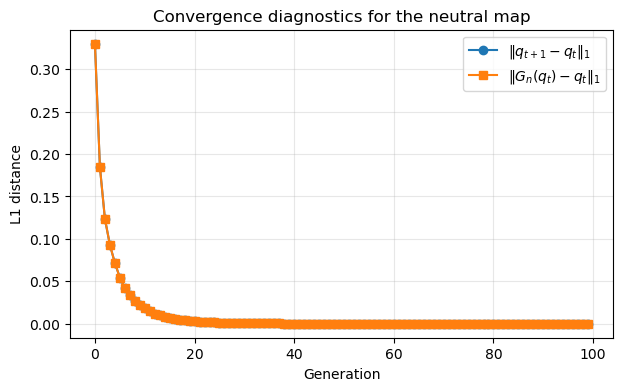

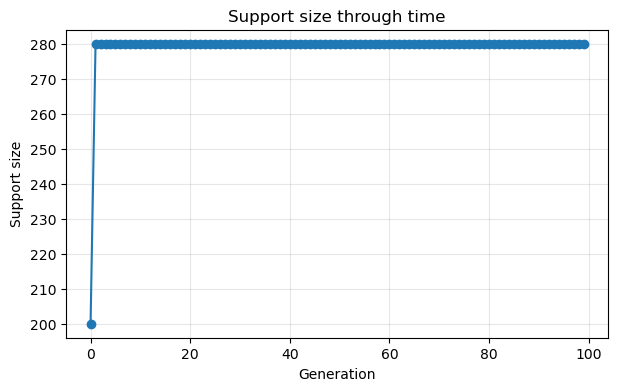

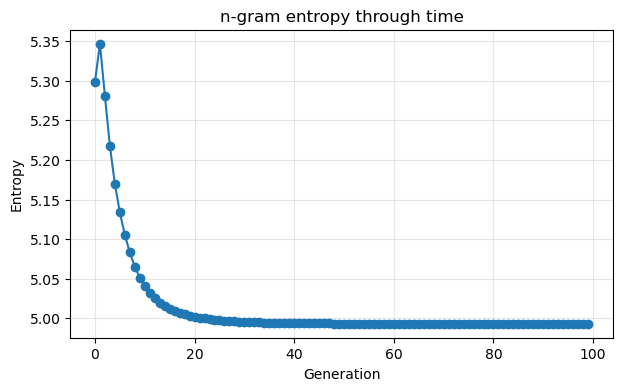

In [5]:

# --- Compact convergence diagnostics ---

history_figures = {}

if not hist.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(hist["generation"], hist["l1_step"], marker="o", label=r"$\|q_{t+1}-q_t\|_1$")
    ax.plot(hist["generation"], hist["rollout_residual"], marker="s", label=r"$\|G_n(q_t)-q_t\|_1$")
    ax.set_xlabel("Generation")
    ax.set_ylabel("L1 distance")
    ax.set_title("Convergence diagnostics for the neutral map")
    ax.grid(True, alpha=0.3)
    ax.legend()
    history_figures["plot_convergence_l1"] = fig
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(hist["generation"], hist["support_size"], marker="o")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Support size")
    ax.set_title("Support size through time")
    ax.grid(True, alpha=0.3)
    history_figures["plot_support_size"] = fig
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(hist["generation"], hist["entropy"], marker="o")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Entropy")
    ax.set_title("n-gram entropy through time")
    ax.grid(True, alpha=0.3)
    history_figures["plot_entropy"] = fig
    plt.show()


In [6]:

# --- Final compact summary ---

last_step = float(hist["l1_step"].iloc[-1]) if not hist.empty else float("nan")
last_residual = float(hist["rollout_residual"].iloc[-1]) if not hist.empty else float("nan")

print("Final summary")
print("-------------")
print(f"Final support size = {len(q_final)}")
print(f"Final n-gram entropy = {entropy(q_final):.6f}")
print(f"Last step L1 distance = {last_step:.6e}")
print(f"Last rollout residual = {last_residual:.6e}")

status_text = "Status: insufficient history to assess convergence."
if np.isfinite(last_step):
    if last_step < tol and set(hist['mode']) == {'exact'}:
        status_text = "Status: exact run reached the requested tolerance."
    elif last_step < 1e-3:
        status_text = "Status: the map appears numerically close to a fixed point."
    else:
        status_text = "Status: not yet near the tolerance; increase iterations or sample budget if needed."
    print(status_text)

print("\nFinal marginal summary")
final_marginal_df = marginal_summary(mu_final)
display(final_marginal_df)

print("\nTop final n-grams")
final_top_df = top_items(q_final, top_k=min(show_top_final, len(q_final)))
display(final_top_df)


Final summary
-------------
Final support size = 280
Final n-gram entropy = 4.993125
Last step L1 distance = 1.536614e-07
Last rollout residual = 1.536614e-07
Status: the map appears numerically close to a fixed point.

Final marginal summary


,k,distinct_kgrams,entropy
0,1,10,2.268690
1,2,99,4.207237
2,3,280,4.993125



Top final n-grams


,ngram,probability
0,195,0.028832
1,588,0.022621
2,007,0.022167
3,800,0.021455
4,885,0.020898
5,884,0.020898
6,311,0.016423
7,848,0.015215
8,841,0.015215
9,845,0.015215


In [7]:

# --- Optional local Lipschitz / contraction probe for Q_{n,alpha} ---

probe_df = None
probe_mean_ratio = None
probe_max_ratio = None

if run_local_probe:
    probe_df = local_lipschitz_probe(
        q=q_final,
        V=V,
        n=n,
        alpha=alpha,
        rollout_mode="exact" if rollout_mode != "sample" else "sample",
        exact_max_states=exact_max_states,
        num_rollout_samples=num_rollout_samples,
        min_context_mass=min_context_mass,
        seed=seed,
        probe_count=probe_count,
        probe_epsilon=probe_epsilon,
    )
    display(probe_df)
    probe_mean_ratio = float(probe_df["ratio"].mean())
    probe_max_ratio = float(probe_df["ratio"].max())
    print("Mean ratio =", probe_mean_ratio)
    print("Max ratio  =", probe_max_ratio)
else:
    print("Local contraction probe is disabled. Set run_local_probe = True to run it.")


,probe,input_l1,output_l1,ratio
0,0,0.023004,0.017857,0.776269
1,1,0.021543,0.017969,0.834126
2,2,0.022027,0.018331,0.832190
3,3,0.022863,0.019029,0.832305
4,4,0.020851,0.017553,0.841843
5,5,0.023009,0.019391,0.842766
6,6,0.023322,0.019015,0.815346
7,7,0.021742,0.017956,0.825857


Mean ratio = 0.8250875669851285
Max ratio  = 0.8427663602529679



## Notes

- The theorem-faithful back-off setting is `min_context_mass = 0.0`.
- If you raise `min_context_mass`, you are intentionally forcing extra back-off on rare contexts.
- In `rollout_mode="auto"`, the notebook uses **exact** rollout whenever it stays manageable, and otherwise falls back to **sampling**.
- Exact convergence is meaningful only when the rollout itself is exact.
- In sampled mode, a small nonzero residual can simply reflect Monte Carlo noise.
- When `save_outputs = True`, each run writes tables, summary files, and plots into a timestamped folder under `outputs/ngram_population_large_scale_theorem1/`.

This notebook studies the **deterministic population map** \(Q_{n,\alpha}\) (or a Monte Carlo approximation to it).
It does **not** simulate finite-corpus Wright--Fisher noise generation by generation.


In [8]:

# --- Save notebook outputs to a run-specific folder ---

run_slug = build_run_slug(
    V=V,
    n=n,
    init_mode=init_mode,
    support_size=support_size,
    text_length=text_length,
    seed=seed,
    alpha=alpha,
    iterations=iterations,
    rollout_mode=rollout_mode,
    min_context_mass=min_context_mass,
    run_label=run_label,
)

run_manifest = {
    "run_slug": run_slug,
    "saved_at": datetime.now().isoformat(timespec="seconds"),
    "notebook": "ngram_population_large_scale_theorem1.ipynb",
    "config": {
        "V": int(V),
        "n": int(n),
        "init_mode": init_mode,
        "support_size": int(support_size),
        "text_length": int(text_length),
        "seed": int(seed),
        "alpha": float(alpha),
        "iterations": int(iterations),
        "rollout_mode": rollout_mode,
        "exact_max_states": int(exact_max_states),
        "num_rollout_samples": int(num_rollout_samples),
        "min_context_mass": float(min_context_mass),
        "tol": float(tol),
        "show_summary_every": int(show_summary_every),
        "show_top_final": int(show_top_final),
        "run_local_probe": bool(run_local_probe),
        "probe_count": int(probe_count),
        "probe_epsilon": float(probe_epsilon),
        "save_outputs": bool(save_outputs),
        "output_root_dir": str(output_root_dir),
        "save_full_distributions": bool(save_full_distributions),
        "run_label": run_label,
    },
    "initial_metrics": {
        "support_size": int(len(q0)),
        "entropy": float(entropy(q0)),
    },
    "final_metrics": {
        "support_size": int(len(q_final)),
        "entropy": float(entropy(q_final)),
        "last_step_l1": None if not np.isfinite(last_step) else float(last_step),
        "last_rollout_residual": None if not np.isfinite(last_residual) else float(last_residual),
        "status": status_text,
    },
    "history": {
        "steps_completed": int(len(hist)),
        "modes_used": sorted(hist["mode"].unique().tolist()) if not hist.empty else [],
    },
    "local_probe": {
        "enabled": bool(run_local_probe),
        "mean_ratio": probe_mean_ratio,
        "max_ratio": probe_max_ratio,
    },
}

summary_lines = [
    f"run_slug: {run_slug}",
    f"saved_at: {run_manifest['saved_at']}",
    "",
    "Configuration",
    f"- V = {V}",
    f"- n = {n}",
    f"- init_mode = {init_mode}",
    f"- support_size = {support_size}" if init_mode.startswith("random_support") else f"- text_length = {text_length}",
    f"- seed = {seed}",
    f"- alpha = {alpha}",
    f"- iterations = {iterations}",
    f"- rollout_mode = {rollout_mode}",
    f"- min_context_mass = {min_context_mass}",
    "",
    "Initial",
    f"- support_size = {len(q0)}",
    f"- entropy = {entropy(q0):.6f}",
    "",
    "Final",
    f"- support_size = {len(q_final)}",
    f"- entropy = {entropy(q_final):.6f}",
    f"- last_step_l1 = {last_step:.6e}" if np.isfinite(last_step) else "- last_step_l1 = nan",
    f"- last_rollout_residual = {last_residual:.6e}" if np.isfinite(last_residual) else "- last_rollout_residual = nan",
    f"- {status_text}",
]
if probe_df is not None:
    summary_lines.extend([
        "",
        "Local probe",
        f"- mean_ratio = {probe_mean_ratio:.6f}",
        f"- max_ratio = {probe_max_ratio:.6f}",
    ])

if save_outputs:
    saved_run_dir, saved_files = save_run_outputs(
        output_root_dir=output_root_dir,
        run_slug=run_slug,
        manifest=run_manifest,
        summary_lines=summary_lines,
        initial_marginal_df=initial_marginal_df,
        initial_top_df=initial_top_df,
        compact_hist_df=compact_hist_df,
        hist=hist,
        final_marginal_df=final_marginal_df,
        final_top_df=final_top_df,
        q0=q0,
        q_final=q_final,
        history_figures=history_figures,
        probe_df=probe_df,
        save_full_distributions=save_full_distributions,
    )
    print(f"Saved run outputs to: {saved_run_dir}")
    display(pd.DataFrame({"saved_file": saved_files}))
else:
    print("save_outputs = False, so no files were written.")


Saved run outputs to: /Users/sorenriis/Documents/Collaboration/GitHub/notebooks/basic_theory/outputs/ngram_population_large_scale_theorem1/20260308_215223_seed7_V10_n3_random_support_uniform_R200_alpha1_iter100_modeauto


,saved_file
0,run_manifest.json
1,summary.txt
2,initial_marginal_summary.csv
3,initial_top_ngrams.csv
4,history_full.csv
5,history_compact.csv
6,final_marginal_summary.csv
7,final_top_ngrams.csv
8,initial_distribution_full.csv
9,final_distribution_full.csv
